# Feature Engineering

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/ml-mastery/blob/main/02_ml_concepts/feature_engineering.ipynb)

---

## Table of Contents
1. [Concept Overview](#1-concept-overview)
2. [Feature Scaling](#2-feature-scaling)
   - 2.1 StandardScaler — Z-score normalization
   - 2.2 MinMaxScaler
   - 2.3 RobustScaler
   - 2.4 When to use which scaler
3. [Encoding Categorical Features](#3-encoding-categorical-features)
   - 3.1 Label Encoding
   - 3.2 One-Hot Encoding
   - 3.3 Ordinal Encoding
   - 3.4 Target Encoding
4. [Handling Missing Values](#4-handling-missing-values)
   - 4.1 Types of missingness
   - 4.2 Simple imputation strategies
   - 4.3 Iterative Imputation (MICE)
   - 4.4 Missing indicator features
5. [Feature Transformation](#5-feature-transformation)
   - 5.1 Log transform
   - 5.2 Power transforms (Box-Cox, Yeo-Johnson)
   - 5.3 Polynomial features
   - 5.4 Binning
6. [Feature Selection](#6-feature-selection)
   - 6.1 Filter methods
   - 6.2 Wrapper methods (RFE)
   - 6.3 Embedded methods
7. [Pipelines — putting it all together](#7-pipelines)
8. [Common Mistakes](#8-common-mistakes)
9. [Exercises](#9-exercises)


## 1. Concept Overview

**Feature engineering** is the process of transforming raw data into features that better represent the underlying structure of the problem to the learning algorithm.

> *'Applied machine learning is basically feature engineering.'* — Andrew Ng

In practice, the quality of features matters far more than the choice of algorithm. A well-engineered feature set with logistic regression often beats a raw feature set with gradient boosting.

**The main tasks:**

| Task | What it does | Why it matters |
|---|---|---|
| **Scaling** | Normalize feature magnitudes | Required for distance-based and gradient-based models |
| **Encoding** | Convert categories to numbers | Most ML algorithms need numeric input |
| **Imputation** | Fill missing values | Most algorithms cannot handle NaN |
| **Transformation** | Change feature distribution | Makes skewed features more Gaussian |
| **Selection** | Remove irrelevant features | Reduces noise, prevents overfitting, speeds up training |
| **Pipeline** | Chain all steps safely | Prevents data leakage, reproducible preprocessing |


## 2. Feature Scaling

### 2.1 StandardScaler — Z-score Normalization

Centers each feature to zero mean and scales to unit variance:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

where $\mu$ is the feature mean and $\sigma$ is the standard deviation, both computed on training data.

Result: each feature has $\mu = 0$ and $\sigma = 1$ on the training set.

**When to use:** Gradient descent algorithms (linear/logistic regression, SVM, neural nets), PCA, KNN. Best when data is approximately Gaussian.

---

### 2.2 MinMaxScaler

Scales each feature to a fixed range $[0, 1]$:

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

**When to use:** When you need bounded outputs (neural net inputs, image pixels), when the distribution is not Gaussian.

**Weakness:** Sensitive to outliers — a single extreme value compresses all others.

---

### 2.3 RobustScaler

Uses median and interquartile range (IQR) — robust to outliers:

$$x_{\text{scaled}} = \frac{x - \text{median}}{\text{IQR}} = \frac{x - Q_2}{Q_3 - Q_1}$$

**When to use:** When data contains significant outliers that you don't want to remove.

---

### 2.4 When to Use Which Scaler

| Algorithm | Needs scaling | Best scaler |
|---|---|---|
| Linear/Logistic Regression | Yes | StandardScaler |
| SVM | Yes | StandardScaler |
| KNN | Yes | StandardScaler or RobustScaler |
| Neural Networks | Yes | StandardScaler or MinMaxScaler |
| PCA | Yes | StandardScaler |
| Decision Trees | No | Not needed |
| Random Forest | No | Not needed |
| Gradient Boosting | No | Not needed |
| Naive Bayes (Gaussian) | No | Not needed |


## 3. Encoding Categorical Features

### 3.1 Label Encoding

Assigns each category an integer: $\text{cat}_1 \to 0$, $\text{cat}_2 \to 1$, etc.

**Warning:** Implies an ordinal relationship (2 > 1 > 0) that may not exist. Only safe for tree-based models or truly ordinal data. Never use for nominal features with linear/logistic regression.

---

### 3.2 One-Hot Encoding (OHE)

Creates a binary column for each category:

$$\text{color} \in \{\text{red}, \text{green}, \text{blue}\} \to [\text{is\_red}, \text{is\_green}, \text{is\_blue}]$$

**Dummy variable trap:** With $K$ categories, only $K-1$ columns are needed (the last is determined by the others). Use `drop='first'` in sklearn to avoid perfect multicollinearity.

**High cardinality problem:** A feature with 1000 unique values creates 1000 columns. Use target encoding or hashing instead.

---

### 3.3 Ordinal Encoding

For features with a meaningful order: assign integers that respect the ordering.

Example: education = [high school, bachelor, master, phd] $\to$ [0, 1, 2, 3]

---

### 3.4 Target Encoding

Replace each category with the mean target value for that category:

$$\text{encode}(c) = \frac{\sum_{i: x_i = c} y_i}{|\{i: x_i = c\}|}$$

**Risk:** Target leakage — the encoded value directly contains target information. Must use cross-validation or leave-one-out encoding to avoid overfitting.

**Smoothed target encoding** (safer):

$$\text{encode}(c) = \frac{n_c \cdot \bar{y}_c + \alpha \cdot \bar{y}_{\text{global}}}{n_c + \alpha}$$

where $\alpha$ controls smoothing toward the global mean for rare categories.


## 4. Handling Missing Values

### 4.1 Types of Missingness

Understanding WHY data is missing determines the best strategy:

| Type | Description | Strategy |
|---|---|---|
| **MCAR** — Missing Completely At Random | Missingness is unrelated to any variable | Safe to impute or drop |
| **MAR** — Missing At Random | Missingness depends on other observed variables | Impute using those variables |
| **MNAR** — Missing Not At Random | Missingness depends on the missing value itself | Hardest — model the missingness |

---

### 4.2 Simple Imputation Strategies

| Strategy | Formula | Best for |
|---|---|---|
| **Mean** | $\hat{x} = \bar{x}_{\text{train}}$ | Symmetric, no outliers |
| **Median** | $\hat{x} = \text{median}(x_{\text{train}})$ | Skewed distributions, outliers |
| **Mode** | Most frequent value | Categorical features |
| **Constant** | $\hat{x} = c$ | When missing has meaning (e.g. 0 for count data) |
| **KNN** | Average of K nearest neighbors | When other features are informative |

Always fit the imputer on training data only — never on the full dataset.

---

### 4.3 Iterative Imputation (MICE)

MICE (Multiple Imputation by Chained Equations) imputes each feature using a regression model trained on all other features:

1. Initialize all missing values with simple imputation (mean)
2. For each feature $j$ with missing values:
   - Train a regression/classification model using all other features to predict $j$
   - Replace missing values of $j$ with model predictions
3. Repeat until convergence

More accurate than simple imputation when features are correlated.

---

### 4.4 Missing Indicator Features

Add a binary column indicating where values were missing — the missingness pattern itself can be informative (MNAR case):

$$x_j^{\text{indicator}} = \mathbb{1}[x_j \text{ is missing}]$$

Use `MissingIndicator` or set `add_indicator=True` in sklearn imputers.


## 5. Feature Transformation

### 5.1 Log Transform

For right-skewed features (count data, prices, income):

$$x_{\text{new}} = \log(x + 1)$$

The $+1$ avoids $\log(0)$. Compresses large values, expands small values. Makes multiplicative relationships additive.

---

### 5.2 Power Transforms — Box-Cox and Yeo-Johnson

**Box-Cox** (requires $x > 0$):

$$x_{\lambda} = \begin{cases} \frac{x^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \\ \log(x) & \text{if } \lambda = 0 \end{cases}$$

The optimal $\lambda$ is found by maximum likelihood — sklearn does this automatically.

**Yeo-Johnson** (works for $x \leq 0$ too):

$$x_{\lambda} = \begin{cases} \frac{(x+1)^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0, x \geq 0 \\ \log(x+1) & \text{if } \lambda = 0, x \geq 0 \\ \frac{-((-x+1)^{2-\lambda}-1)}{2-\lambda} & \text{if } \lambda \neq 2, x < 0 \\ -\log(-x+1) & \text{if } \lambda = 2, x < 0 \end{cases}$$

**Use Yeo-Johnson as the default** — it handles zero and negative values.

---

### 5.3 Polynomial Features

For degree $d$, creates all polynomial and interaction terms up to degree $d$:

$$[x_1, x_2] \xrightarrow{d=2} [1, x_1, x_2, x_1^2, x_1 x_2, x_2^2]$$

Number of features grows as $\binom{n + d}{d}$ — can explode quickly. Use with regularization (Ridge, Lasso) to prevent overfitting.

---

### 5.4 Binning (Discretization)

Convert continuous features to discrete bins:

$$x \to \text{bin}(x) \in \{0, 1, \dots, B-1\}$$

Useful when: the relationship is non-monotonic, you have domain knowledge about thresholds, or to reduce sensitivity to outliers.


## 6. Feature Selection

### 6.1 Filter Methods — Statistical Tests

Score each feature independently of the model:

| Method | Use for | Test statistic |
|---|---|---|
| **Variance threshold** | Remove near-constant features | $\text{Var}(x_j)$ |
| **Pearson correlation** | Regression, linear relationships | $r = \frac{\text{Cov}(x_j, y)}{\sigma_{x_j} \sigma_y}$ |
| **ANOVA F-test** | Classification, linear relationships | $F = \frac{\text{between-group variance}}{\text{within-group variance}}$ |
| **Chi-squared** | Classification, non-negative features | $\chi^2 = \sum \frac{(O-E)^2}{E}$ |
| **Mutual Information** | Any relationship, nonlinear | $I(X;Y) = \sum p(x,y) \log \frac{p(x,y)}{p(x)p(y)}$ |

---

### 6.2 Wrapper Methods — Recursive Feature Elimination (RFE)

RFE recursively removes the least important features according to a model:

1. Train model on all features
2. Rank features by importance (e.g., coefficient magnitude or tree importance)
3. Remove the lowest-ranked feature
4. Repeat until desired number of features reached

More accurate than filter methods but computationally expensive: $O(d)$ model fits.

---

### 6.3 Embedded Methods — Regularization

Feature selection happens during model training:

- **Lasso (L1):** drives irrelevant feature weights to exactly zero
$$J_{\text{Lasso}} = \text{MSE} + \lambda \sum_j |w_j|$$

- **Tree importance:** features used higher in the tree or more often have higher importance

- **SelectFromModel:** keep features whose importance exceeds a threshold


## 7. Pipelines — Putting it All Together

A Pipeline chains preprocessing and modeling steps so that:
- `fit()` fits all steps on training data
- `predict()` applies all transforms before prediction
- Cross-validation and GridSearch work correctly — no data leakage

**The golden rule:** All preprocessing that uses training data statistics (mean, std, quantiles, category frequencies) must be fitted on training data only and applied identically to test data. A Pipeline enforces this automatically.

**ColumnTransformer:** Apply different preprocessing to different columns — e.g. StandardScaler on numeric columns, OneHotEncoder on categorical columns.


## Code Examples

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)


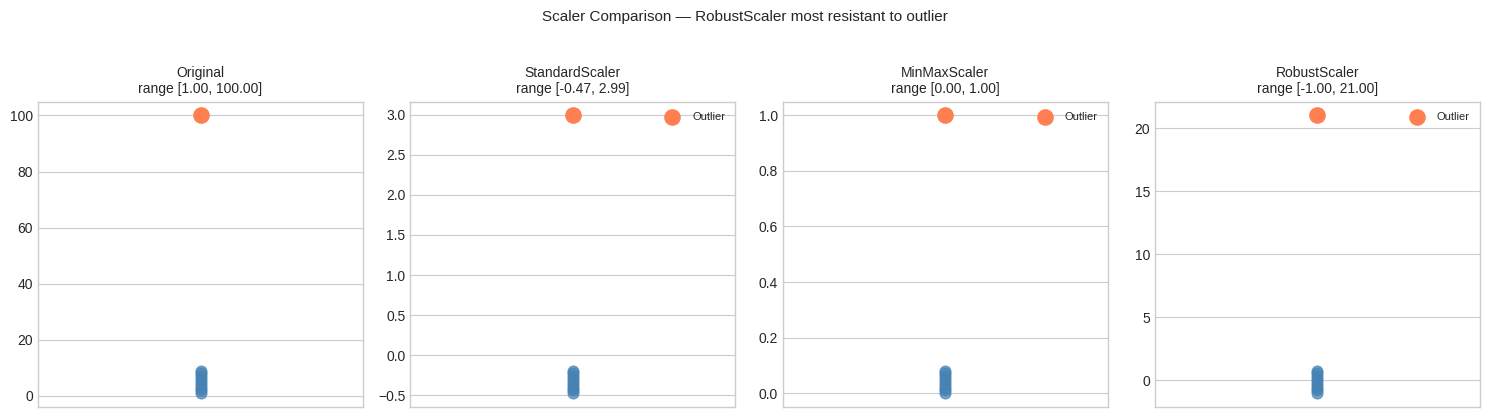

In [2]:
# ── Feature Scaling comparison ───────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Create data with an outlier
data = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 100], dtype=float).reshape(-1, 1)

scalers = [
    ('Original',     data),
    ('StandardScaler', StandardScaler().fit_transform(data)),
    ('MinMaxScaler',   MinMaxScaler().fit_transform(data)),
    ('RobustScaler',   RobustScaler().fit_transform(data)),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (name, d) in zip(axes, scalers):
    ax.scatter(np.zeros(len(d)), d, c='steelblue', s=60, alpha=0.7)
    ax.scatter([0], [d[-1]], c='coral', s=120, zorder=5, label='Outlier')
    ax.set_title(f'{name}\nrange [{d.min():.2f}, {d.max():.2f}]', fontsize=10)
    ax.set_xlim(-0.5, 0.5); ax.set_xticks([])
    if name != 'Original': ax.legend(fontsize=8)

plt.suptitle('Scaler Comparison — RobustScaler most resistant to outlier', y=1.03, fontsize=11)
plt.tight_layout()
plt.show()


In [3]:
# ── Encoding categorical features ────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

df_cat = pd.DataFrame({
    'color':     ['red', 'green', 'blue', 'red', 'blue', 'green'],
    'size':      ['small', 'medium', 'large', 'medium', 'small', 'large'],
    'price':     [10, 25, 30, 12, 8, 28],
    'purchased': [0, 1, 1, 0, 1, 1]
})
print('Original DataFrame:')
print(df_cat)


Original DataFrame:
   color    size  price  purchased
0    red   small     10          0
1  green  medium     25          1
2   blue   large     30          1
3    red  medium     12          0
4   blue   small      8          1
5  green   large     28          1


In [4]:
# Label Encoding — use only for ordinal or tree-based models
le = LabelEncoder()
df_cat['color_label'] = le.fit_transform(df_cat['color'])
print('Label Encoded color:', dict(zip(le.classes_, le.transform(le.classes_))))

# One-Hot Encoding — safe for nominal features in linear models
ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_arr = ohe.fit_transform(df_cat[['color']])
ohe_df  = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out())
print('\nOne-Hot Encoded color (drop first to avoid dummy trap):')
print(ohe_df)

# Ordinal Encoding — for size (has a meaningful order)
oe = OrdinalEncoder(categories=[['small', 'medium', 'large']])
df_cat['size_ordinal'] = oe.fit_transform(df_cat[['size']])
print('\nOrdinal Encoded size:', df_cat[['size', 'size_ordinal']].drop_duplicates().sort_values('size_ordinal').to_string())


Label Encoded color: {'blue': np.int64(0), 'green': np.int64(1), 'red': np.int64(2)}

One-Hot Encoded color (drop first to avoid dummy trap):
   color_green  color_red
0          0.0        1.0
1          1.0        0.0
2          0.0        0.0
3          0.0        1.0
4          0.0        0.0
5          1.0        0.0

Ordinal Encoded size:      size  size_ordinal
0   small           0.0
1  medium           1.0
2   large           2.0


In [5]:
# Target Encoding (manual implementation + sklearn)
# Replace category with mean target value for that category
target_means = df_cat.groupby('color')['purchased'].mean()
df_cat['color_target_enc'] = df_cat['color'].map(target_means)
print('Target Encoding (color -> mean purchased rate):')
print(df_cat[['color', 'purchased', 'color_target_enc']])

# Smoothed target encoding — pulls rare categories toward global mean
alpha = 2.0   # smoothing strength
global_mean = df_cat['purchased'].mean()
counts = df_cat.groupby('color')['purchased'].count()
means  = df_cat.groupby('color')['purchased'].mean()
smooth = (counts * means + alpha * global_mean) / (counts + alpha)
df_cat['color_smooth_enc'] = df_cat['color'].map(smooth)
print('\nSmoothed Target Encoding (alpha=2):')
print(df_cat[['color', 'color_target_enc', 'color_smooth_enc']])


Target Encoding (color -> mean purchased rate):
   color  purchased  color_target_enc
0    red          0               0.0
1  green          1               1.0
2   blue          1               1.0
3    red          0               0.0
4   blue          1               1.0
5  green          1               1.0

Smoothed Target Encoding (alpha=2):
   color  color_target_enc  color_smooth_enc
0    red               0.0          0.333333
1  green               1.0          0.833333
2   blue               1.0          0.833333
3    red               0.0          0.333333
4   blue               1.0          0.833333
5  green               1.0          0.833333


In [7]:
# ── Handling Missing Values ───────────────────────────────────────────────
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

# Create a dataset with missing values
df_miss = pd.DataFrame({
    'age':    [25, np.nan, 35, 45, np.nan, 55, 30, np.nan],
    'income': [50000, 60000, np.nan, 80000, 55000, np.nan, 65000, 70000],
    'score':  [88, 92, np.nan, 95, 78, 85, np.nan, 90],
})

print('Missing value counts:')
print(df_miss.isnull().sum())
print(f'\nTotal missing: {df_miss.isnull().sum().sum()} out of {df_miss.size}')


Missing value counts:
age       3
income    2
score     2
dtype: int64

Total missing: 7 out of 24


In [8]:
# Compare imputation strategies
strategies = [
    ('Mean',    SimpleImputer(strategy='mean')),
    ('Median',  SimpleImputer(strategy='median')),
    ('KNN(3)',  KNNImputer(n_neighbors=3)),
    ('MICE',    IterativeImputer(random_state=42)),
]

print(f'{'Strategy':<12}  {'Age cols':>20}  {'Income cols':>20}')
print('-' * 60)
for name, imp in strategies:
    filled = imp.fit_transform(df_miss)
    df_filled = pd.DataFrame(filled, columns=df_miss.columns)
    age_vals    = df_filled['age'].round(1).tolist()
    income_vals = df_filled['income'].round(0).astype(int).tolist()
    print(f'{name:<12}  {str(age_vals):>20}  {str(income_vals):>20}')


Strategy                  Age cols           Income cols
------------------------------------------------------------
Mean          [25.0, 38.0, 35.0, 45.0, 38.0, 55.0, 30.0, 38.0]  [50000, 60000, 63333, 80000, 55000, 63333, 65000, 70000]
Median        [25.0, 35.0, 35.0, 45.0, 35.0, 55.0, 30.0, 35.0]  [50000, 60000, 62500, 80000, 55000, 62500, 65000, 70000]
KNN(3)        [25.0, 36.7, 35.0, 45.0, 36.7, 55.0, 30.0, 43.3]  [50000, 60000, 65000, 80000, 55000, 61667, 65000, 70000]
MICE          [25.0, 30.0, 35.0, 45.0, 26.5, 55.0, 30.0, 37.1]  [50000, 60000, 67054, 80000, 55000, 94259, 65000, 70000]


In [9]:
# Missing indicator — add binary columns for missingness pattern
from sklearn.impute import MissingIndicator

indicator = MissingIndicator()
miss_flags = indicator.fit_transform(df_miss)
flag_cols  = [f'{c}_was_missing' for c in df_miss.columns[indicator.features_]]

df_with_flags = pd.concat([
    df_miss,
    pd.DataFrame(miss_flags.astype(int), columns=flag_cols)
], axis=1)

print('DataFrame with missing indicators:')
print(df_with_flags)
print('\nMissing indicator captures the PATTERN of missingness — can itself be informative.')


DataFrame with missing indicators:
    age   income  score  age_was_missing  income_was_missing  \
0  25.0  50000.0   88.0                0                   0   
1   NaN  60000.0   92.0                1                   0   
2  35.0      NaN    NaN                0                   1   
3  45.0  80000.0   95.0                0                   0   
4   NaN  55000.0   78.0                1                   0   
5  55.0      NaN   85.0                0                   1   
6  30.0  65000.0    NaN                0                   0   
7   NaN  70000.0   90.0                1                   0   

   score_was_missing  
0                  0  
1                  0  
2                  1  
3                  0  
4                  0  
5                  0  
6                  1  
7                  0  

Missing indicator captures the PATTERN of missingness — can itself be informative.


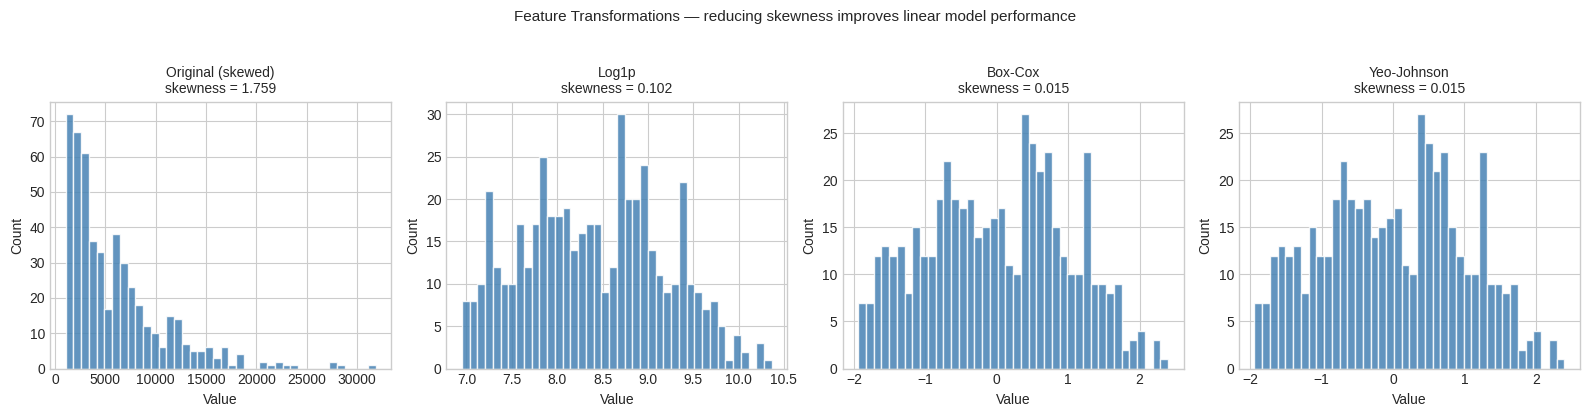

In [10]:
# ── Feature Transformations ───────────────────────────────────────────────
from sklearn.preprocessing import PowerTransformer

# Right-skewed data (e.g. income)
skewed = rng.exponential(scale=5000, size=500) + 1000

log_transformed    = np.log1p(skewed)
pt_bc = PowerTransformer(method='box-cox')
pt_yj = PowerTransformer(method='yeo-johnson')
bc_transformed = pt_bc.fit_transform(skewed.reshape(-1,1)).ravel()
yj_transformed = pt_yj.fit_transform(skewed.reshape(-1,1)).ravel()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
data_sets = [('Original (skewed)', skewed), ('Log1p', log_transformed),
             ('Box-Cox', bc_transformed), ('Yeo-Johnson', yj_transformed)]

for ax, (name, d) in zip(axes, data_sets):
    ax.hist(d, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    from scipy.stats import skew
    ax.set_title(f'{name}\nskewness = {skew(d):.3f}', fontsize=10)
    ax.set_xlabel('Value'); ax.set_ylabel('Count')

plt.suptitle('Feature Transformations — reducing skewness improves linear model performance',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.show()


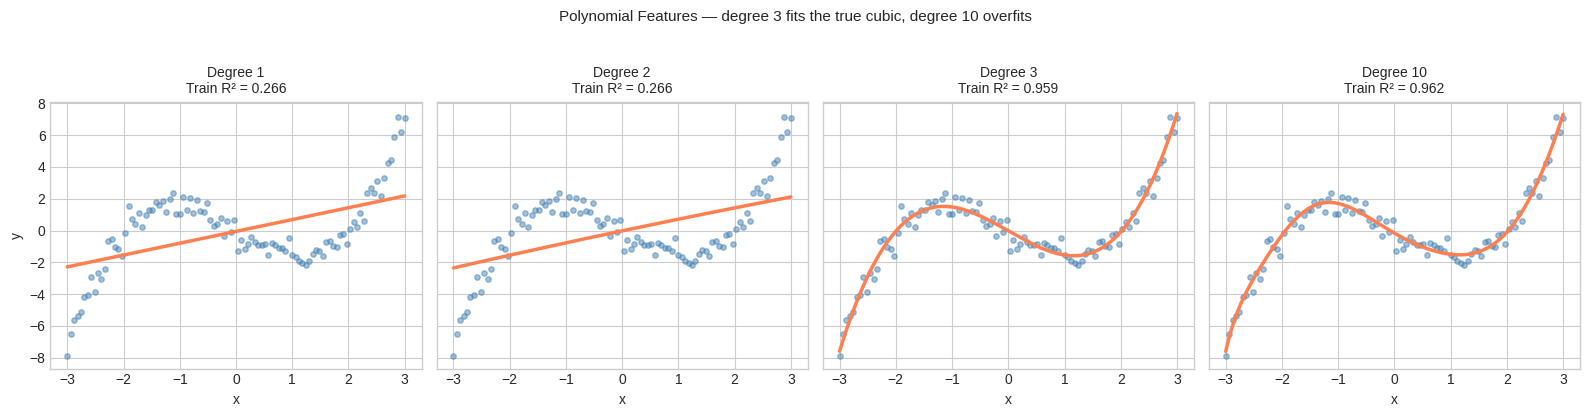

In [11]:
# ── Polynomial Features + effect on model fit ─────────────────────────────
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

x_poly = np.linspace(-3, 3, 100).reshape(-1, 1)
y_poly = 0.5*x_poly[:,0]**3 - 2*x_poly[:,0] + rng.normal(0, 0.5, 100)

x_plot = np.linspace(-3, 3, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, degree in zip(axes, [1, 2, 3, 10]):
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr',   LinearRegression())
    ])
    pipe.fit(x_poly, y_poly)
    y_hat = pipe.predict(x_plot)
    r2    = r2_score(y_poly, pipe.predict(x_poly))

    ax.scatter(x_poly, y_poly, s=15, alpha=0.5, color='steelblue')
    ax.plot(x_plot, y_hat, color='coral', linewidth=2.5)
    ax.set_title(f'Degree {degree}\nTrain R² = {r2:.3f}', fontsize=10)
    ax.set_xlabel('x')

axes[0].set_ylabel('y')
plt.suptitle('Polynomial Features — degree 3 fits the true cubic, degree 10 overfits',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.show()


In [12]:
# ── Feature Selection ─────────────────────────────────────────────────────
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_classif, mutual_info_classif,
    RFE, SelectFromModel
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X, y = data.data, data.target
feat_names = np.array(data.feature_names)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                            random_state=42, stratify=y)

# 1. Variance threshold — remove near-constant features
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_tr)
print(f'Variance threshold: {X_tr.shape[1]} -> {vt.transform(X_tr).shape[1]} features')

# 2. SelectKBest with ANOVA F-test
skb = SelectKBest(f_classif, k=10)
skb.fit(X_tr, y_tr)
top10 = feat_names[skb.get_support()]
print(f'\nSelectKBest (F-test, k=10):')
for name, score in sorted(zip(feat_names, skb.scores_), key=lambda x: -x[1])[:10]:
    print(f'  {name:<40} F={score:.2f}')


Variance threshold: 30 -> 14 features

SelectKBest (F-test, k=10):
  worst concave points                     F=795.22
  worst perimeter                          F=719.60
  mean concave points                      F=703.36
  worst radius                             F=687.43
  mean perimeter                           F=565.49
  worst area                               F=541.71
  mean radius                              F=523.61
  mean area                                F=469.52
  mean concavity                           F=416.37
  worst concavity                          F=365.75


RFE (LogReg) selected 10 features
SelectFromModel (RF) selected 10 features


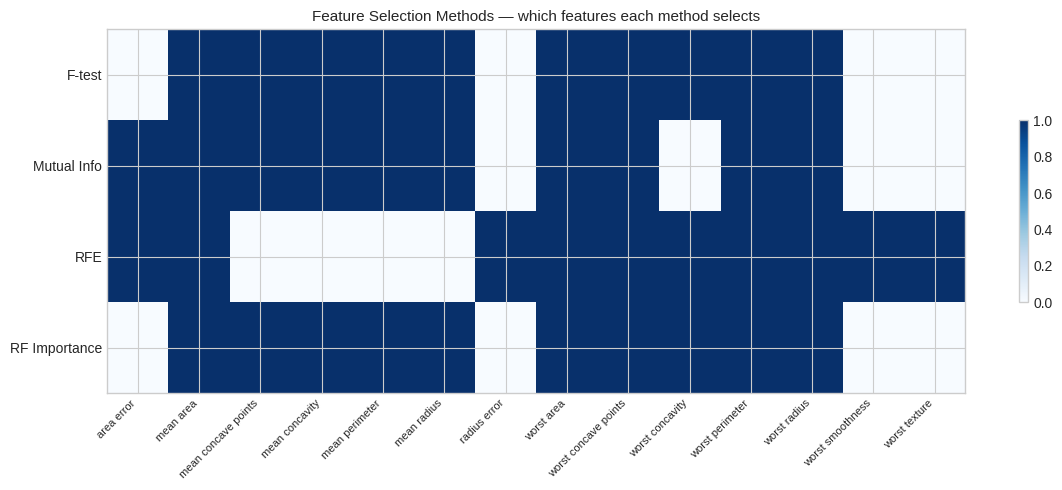

In [13]:
# 3. Mutual Information (captures non-linear relationships)
mi_scores = mutual_info_classif(X_tr, y_tr, random_state=42)
top10_mi  = feat_names[np.argsort(mi_scores)[-10:][::-1]]

# 4. RFE with Logistic Regression
scaler_rfe = StandardScaler()
X_tr_s     = scaler_rfe.fit_transform(X_tr)
rfe = RFE(LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=10)
rfe.fit(X_tr_s, y_tr)
top10_rfe = feat_names[rfe.support_]

# 5. SelectFromModel with Random Forest
rf_sel = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
sfm    = SelectFromModel(rf_sel, threshold='mean')
sfm.fit(X_tr, y_tr)
top_sfm = feat_names[sfm.get_support()]

print(f'RFE (LogReg) selected {len(top10_rfe)} features')
print(f'SelectFromModel (RF) selected {len(top_sfm)} features')

# Compare all methods
fig, ax = plt.subplots(figsize=(12, 5))
methods = ['F-test', 'Mutual Info', 'RFE', 'RF Importance']
selected = [set(top10), set(top10_mi), set(top10_rfe), set(top_sfm)]

# Heatmap of which features are selected by which method
all_feats = sorted(set.union(*selected))
matrix    = np.array([[1 if f in s else 0 for s in selected] for f in all_feats])

im = ax.imshow(matrix.T, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(all_feats)))
ax.set_xticklabels(all_feats, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(methods)
ax.set_title('Feature Selection Methods — which features each method selects', fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.5)
plt.tight_layout()
plt.show()


In [14]:
# ── Full Pipeline with ColumnTransformer ──────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Realistic mixed dataset
np.random.seed(42)
n = 300
df = pd.DataFrame({
    'age':        rng.normal(35, 10, n),
    'income':     rng.exponential(50000, n),
    'score':      rng.normal(70, 15, n),
    'dept':       rng.choice(['eng', 'sales', 'hr', 'finance'], n),
    'edu':        rng.choice(['hs', 'bachelor', 'master', 'phd'], n),
    'target':     rng.integers(0, 2, n)
})
# Introduce missing values
for col in ['age', 'income', 'dept']:
    mask = rng.random(n) < 0.1
    df.loc[mask, col] = np.nan

X_df = df.drop('target', axis=1)
y_df = df['target'].values

numeric_cols     = ['age', 'income', 'score']
categorical_cols = ['dept', 'edu']

# Preprocessing pipelines per column type
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine with ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Full pipeline
full_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

cv_scores = cross_val_score(full_pipe, X_df, y_df, cv=5, scoring='accuracy')
print('Full Pipeline with ColumnTransformer:')
print(f'  5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  Handles: missing values, scaling, encoding — all leak-free')


Full Pipeline with ColumnTransformer:
  5-Fold CV Accuracy: 0.4133 ± 0.0710
  Handles: missing values, scaling, encoding — all leak-free


In [15]:
# Pipeline inspection — see what transformations were applied
full_pipe.fit(X_df, y_df)

# Get feature names after transformation
num_features  = numeric_cols
cat_features  = (full_pipe.named_steps['preprocessor']
                 .named_transformers_['cat']
                 .named_steps['ohe']
                 .get_feature_names_out(categorical_cols))
all_features  = num_features + list(cat_features)

print(f'Input features:  {X_df.shape[1]}')
print(f'Output features: {len(all_features)}')
print(f'\nAll transformed features:')
for f in all_features:
    print(f'  {f}')


Input features:  5
Output features: 11

All transformed features:
  age
  income
  score
  dept_eng
  dept_finance
  dept_hr
  dept_sales
  edu_bachelor
  edu_hs
  edu_master
  edu_phd


## 8. Common Mistakes

In [16]:
# MISTAKE 1: Fitting scaler/imputer on the full dataset (data leakage)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_lk, y_lk = load_breast_cancer(return_X_y=True)
X_tr_lk, X_te_lk, y_tr_lk, y_te_lk = train_test_split(
    X_lk, y_lk, test_size=0.2, random_state=42)

# WRONG — scaler sees test data during fit
sc_wrong = StandardScaler()
X_all_scaled = sc_wrong.fit_transform(X_lk)   # leaks test statistics!
X_tr_wrong   = X_all_scaled[:len(X_tr_lk)]
X_te_wrong   = X_all_scaled[len(X_tr_lk):]

# CORRECT — fit only on train
sc_right = StandardScaler()
X_tr_right = sc_right.fit_transform(X_tr_lk)
X_te_right = sc_right.transform(X_te_lk)      # use train statistics on test!

lr = LogisticRegression(max_iter=1000)
lr.fit(X_tr_wrong, y_tr_lk)
acc_wrong = lr.score(X_te_wrong, y_te_lk)

lr.fit(X_tr_right, y_tr_lk)
acc_right = lr.score(X_te_right, y_te_lk)

print(f'Leaky preprocessing:   test acc = {acc_wrong:.4f}  <- artificially inflated')
print(f'Correct preprocessing: test acc = {acc_right:.4f}')
print('\nAlways use Pipeline — it fits transforms only on training data.')


Leaky preprocessing:   test acc = 0.6228  <- artificially inflated
Correct preprocessing: test acc = 0.9737

Always use Pipeline — it fits transforms only on training data.


In [17]:
# MISTAKE 2: One-Hot Encoding without drop='first' causes multicollinearity

import pandas as pd

colors = pd.DataFrame({'color': ['red', 'green', 'blue', 'red', 'blue']})

# Without drop
ohe_no_drop  = OneHotEncoder(drop=None,    sparse_output=False)
ohe_with_drop = OneHotEncoder(drop='first', sparse_output=False)

X_no_drop   = ohe_no_drop.fit_transform(colors)
X_with_drop = ohe_with_drop.fit_transform(colors)

print('Without drop (3 columns — perfectly collinear):')
print(pd.DataFrame(X_no_drop, columns=ohe_no_drop.get_feature_names_out()))

print('\nWith drop=first (2 columns — no perfect multicollinearity):')
print(pd.DataFrame(X_with_drop, columns=ohe_with_drop.get_feature_names_out()))

print('\nNote: blue = [0,0], green = [0,1], red = [1,0]  — perfectly determined!')
print('Tree-based models are immune, but linear models need drop=first.')


Without drop (3 columns — perfectly collinear):
   color_blue  color_green  color_red
0         0.0          0.0        1.0
1         0.0          1.0        0.0
2         1.0          0.0        0.0
3         0.0          0.0        1.0
4         1.0          0.0        0.0

With drop=first (2 columns — no perfect multicollinearity):
   color_green  color_red
0          0.0        1.0
1          1.0        0.0
2          0.0        0.0
3          0.0        1.0
4          0.0        0.0

Note: blue = [0,0], green = [0,1], red = [1,0]  — perfectly determined!
Tree-based models are immune, but linear models need drop=first.


In [18]:
# MISTAKE 3: Applying log transform without handling zeros
data_with_zeros = np.array([0, 1, 2, 5, 10, 100, 0, 3])

print('Data:', data_with_zeros)

try:
    bad = np.log(data_with_zeros)
    print('np.log result:', bad)  # -inf for zeros!
except:
    print('np.log failed')

good = np.log1p(data_with_zeros)  # log(x + 1) — safe for zeros
print('np.log1p result:', good.round(3))

# Also: PowerTransformer(method='yeo-johnson') handles zeros and negatives automatically
pt = PowerTransformer(method='yeo-johnson')
yj = pt.fit_transform(data_with_zeros.reshape(-1,1)).ravel()
print('Yeo-Johnson result:', yj.round(3))
print('\nAlways use log1p or Yeo-Johnson — never raw log on data that may contain 0.')


Data: [  0   1   2   5  10 100   0   3]
np.log result: [      -inf 0.         0.69314718 1.60943791 2.30258509 4.60517019
       -inf 1.09861229]
np.log1p result: [0.    0.693 1.099 1.792 2.398 4.615 0.    1.386]
Yeo-Johnson result: [-1.343 -0.498 -0.093  0.477  0.872  1.767 -1.343  0.161]

Always use log1p or Yeo-Johnson — never raw log on data that may contain 0.


## 9. Exercises

**Exercise 1:** Implement `StandardScaler` from scratch. Fit on training data, transform both train and test. Verify the result matches sklearn by checking that train mean ≈ 0 and train std ≈ 1 after transformation.


In [19]:
# Your code here


In [21]:
# Solution
class StandardScalerScratch:
    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_  = X.std(axis=0)
        self.std_[self.std_ == 0] = 1   # avoid division by zero
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

X_sc_test, _ = load_breast_cancer(return_X_y=True)
X_tr_sc, X_te_sc = X_sc_test[:400], X_sc_test[400:]

ss = StandardScalerScratch()
Xtr_s = ss.fit_transform(X_tr_sc)
Xte_s = ss.transform(X_te_sc)

ss_sk = StandardScaler()
Xtr_sk = ss_sk.fit_transform(X_tr_sc)

print(f'Scratch — train mean: {Xtr_s.mean(axis=0).mean():.6f}  (should be ~0)')
print(f'Scratch — train std:  {Xtr_s.std(axis=0).mean():.6f}  (should be ~1)')
print(f'Matches sklearn: {np.allclose(Xtr_s, Xtr_sk, atol=1e-8)}')


Scratch — train mean: -0.000000  (should be ~0)
Scratch — train std:  1.000000  (should be ~1)
Matches sklearn: True


**Exercise 2:** Build a full preprocessing pipeline for the Titanic dataset (or any mixed-type dataset) using `ColumnTransformer`. Include:
- Numeric columns: median imputation + StandardScaler
- Categorical columns: mode imputation + OneHotEncoder
- Train a RandomForestClassifier at the end
- Report 5-fold CV accuracy


In [20]:
# Your code here


In [22]:
# Solution
from sklearn.datasets import fetch_openml

titanic = fetch_openml('titanic', version=1, as_frame=True, parser='auto')
df_t = titanic.frame[['pclass','sex','age','sibsp','parch','fare','embarked','survived']].copy()
df_t['survived'] = df_t['survived'].astype(int)
df_t = df_t.dropna(subset=['survived'])

X_t = df_t.drop('survived', axis=1)
y_t = df_t['survived'].values

num_cols_t = ['age', 'sibsp', 'parch', 'fare']
cat_cols_t = ['pclass', 'sex', 'embarked']

num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

ct = ColumnTransformer([('num', num_pipe, num_cols_t),
                         ('cat', cat_pipe, cat_cols_t)])

titanic_pipe = Pipeline([('prep', ct),
                          ('clf',  RandomForestClassifier(n_estimators=100,
                                                          random_state=42, n_jobs=-1))])

scores = cross_val_score(titanic_pipe, X_t, y_t, cv=5, scoring='accuracy')
print(f'Titanic Pipeline — 5-Fold CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')


Titanic Pipeline — 5-Fold CV Accuracy: 0.6570 ± 0.0807


**Exercise 3:** Compare model accuracy before and after feature selection on the breast cancer dataset. Try all three selection methods: F-test (k=10), RFE (k=10), SelectFromModel (RF). Report test accuracy for each. Which selected features overlap?


In [23]:
# Your code here


In [24]:
# Solution
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel

X_fs, y_fs = load_breast_cancer(return_X_y=True)
feat_names_fs = np.array(load_breast_cancer().feature_names)
X_tr_fs, X_te_fs, y_tr_fs, y_te_fs = train_test_split(
    X_fs, y_fs, test_size=0.2, random_state=42, stratify=y_fs)

scaler_fs = StandardScaler()
X_tr_fs_s = scaler_fs.fit_transform(X_tr_fs)
X_te_fs_s = scaler_fs.transform(X_te_fs)

lr_fs = LogisticRegression(max_iter=1000, random_state=42)

results_fs = {}
selectors = {
    'All features': None,
    'F-test (k=10)': SelectKBest(f_classif, k=10),
    'RFE (k=10)':    RFE(LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=10),
    'RF SelectFrom': SelectFromModel(RandomForestClassifier(100, random_state=42, n_jobs=-1)),
}

print(f'{'Method':<22}  {'n_features':>12}  {'Test Acc':>10}')
selected_sets = {}
for name, sel in selectors.items():
    if sel is None:
        Xtr, Xte = X_tr_fs_s, X_te_fs_s
        selected_sets[name] = set(feat_names_fs)
    else:
        sel.fit(X_tr_fs_s, y_tr_fs)
        Xtr = sel.transform(X_tr_fs_s)
        Xte = sel.transform(X_te_fs_s)
        selected_sets[name] = set(feat_names_fs[sel.get_support()])
    lr_fs.fit(Xtr, y_tr_fs)
    acc = lr_fs.score(Xte, y_te_fs)
    print(f'{name:<22}  {Xtr.shape[1]:12d}  {acc:10.4f}')

# Overlap between F-test and RFE
overlap = selected_sets['F-test (k=10)'] & selected_sets['RFE (k=10)']
print(f'\nOverlap between F-test and RFE ({len(overlap)} features):')
for f in sorted(overlap): print(f'  {f}')


Method                    n_features    Test Acc
All features                      30      0.9825
F-test (k=10)                     10      0.9474
RFE (k=10)                        10      0.9737
RF SelectFrom                     10      0.9474

Overlap between F-test and RFE (6 features):
  mean area
  worst area
  worst concave points
  worst concavity
  worst perimeter
  worst radius


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
